# Electrical Energy Demand Forecast
- Problem statement: "How much electricity will consumers use in the future?"
- Solution: Build an automated short-term electricity demand forecasting system for Singapore using NEMS market data API. 
    - The system collects new market data daily, engineers time-series features, trains forecasting models, evaluates forecast accuracy, and predicts demand for the next 24 hours.
- This project uses Singapore energy NEMS API endpoint for models to predict future energy demand overtime.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    make_scorer
)

## 1. Data Exploration

In [16]:
df = pd.read_csv("month.csv")

df.columns = [c.strip() for c in df.columns]

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["start_time"] = df["Period"].str.split("-").str[0]


In [17]:
# combine start time and date
df["timestamp"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d") + " " + df["start_time"]
)

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,Date,Period,Demand (MW),Solar (MW),TCL (MW),USEP ($/MWh),EHEUR ($/MWh),LCP ($/MWh),RUSEP ($/MWh),MAP ($/MWh),MAPT ($/MWh),TPC Applied,Last Updated,start_time,timestamp
0,2025-12-18,00:00-00:30,5932.252,0.0,0.0,78.34,-0.32,0.0,78.34,79.22,533.4,No,18 Dec 2025 11:31:31 PM,00:00,2025-12-18 00:00:00
1,2025-12-18,00:30-01:00,5814.980,0.0,0.0,78.19,-0.30,0.0,78.19,79.28,533.4,No,18 Dec 2025 11:31:31 PM,00:30,2025-12-18 00:30:00
2,2025-12-18,01:00-01:30,5756.309,0.0,0.0,78.35,-0.29,0.0,78.35,79.33,533.4,No,18 Dec 2025 11:31:31 PM,01:00,2025-12-18 01:00:00
3,2025-12-18,01:30-02:00,5691.117,0.0,0.0,78.22,-0.28,0.0,78.22,79.39,533.4,No,18 Dec 2025 11:31:31 PM,01:30,2025-12-18 01:30:00
4,2025-12-18,02:00-02:30,5639.852,0.0,0.0,75.83,-0.27,0.0,75.83,79.4,533.4,No,18 Dec 2025 11:31:31 PM,02:00,2025-12-18 02:00:00


In [18]:
df.corr(numeric_only=True)["Demand (MW)"].sort_values(ascending=False)

Demand (MW)      1.000000
USEP ($/MWh)     0.504144
LCP ($/MWh)      0.097776
TCL (MW)         0.096150
EHEUR ($/MWh)   -0.036373
Solar (MW)      -0.042929
Name: Demand (MW), dtype: float64

In [19]:
# drop irrevelant features
df = df[[
    "timestamp",
    "Demand (MW)",
    "Solar (MW)",
    "USEP ($/MWh)"
]].copy()

df.columns = [
    "timestamp",
    "demand",
    "solar",
    "usep"
]
 
df.head()


,timestamp,demand,solar,usep
0,2025-12-18 00:00:00,5932.252,0.0,78.34
1,2025-12-18 00:30:00,5814.980,0.0,78.19
2,2025-12-18 01:00:00,5756.309,0.0,78.35
3,2025-12-18 01:30:00,5691.117,0.0,78.22
4,2025-12-18 02:00:00,5639.852,0.0,75.83


In [20]:
print('Number of rows: ' + str(df.shape[0]))
print('Number of duplicate rows: ' + str(df.duplicated().sum()))
print('_' * 40)
print(f"{df.info()}")

Number of rows: 8736
Number of duplicate rows: 0
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8736 entries, 0 to 8735
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8736 non-null   datetime64[ns]
 1   demand     8736 non-null   float64       
 2   solar      8736 non-null   float64       
 3   usep       8736 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 273.1 KB
None


In [21]:
# Check for unqiue values
for col in df.columns: 
    print(f"{col} : {df[col].nunique()} unique values")
print('_'*70)

# Check for any outliers and count
df.describe()

timestamp : 8736 unique values
demand : 8662 unique values
solar : 4425 unique values
usep : 5864 unique values
______________________________________________________________________


,timestamp,demand,solar,usep
count,8736,8736.000000,8736.000000,8736.000000
mean,2026-03-18 23:45:00,6609.001407,274.590294,158.001532
min,2025-12-18 00:00:00,5224.822000,0.000000,51.340000
25%,2026-02-01 11:52:30,6181.631250,0.000000,105.340000
50%,2026-03-18 23:45:00,6605.587000,5.645000,161.660000
75%,2026-05-03 11:37:30,7033.231000,546.490000,181.862500
max,2026-06-17 23:30:00,7876.312000,1480.750000,1208.200000
std,NaN,533.220701,378.344837,66.658917


In [22]:
# Convert into timestep from string into datetime64[ns]
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df.set_index("timestamp")

df = df.asfreq("30min")

df.head()

,demand,solar,usep
timestamp,,,
2025-12-18 00:00:00,5932.252,0.0,78.34
2025-12-18 00:30:00,5814.980,0.0,78.19
2025-12-18 01:00:00,5756.309,0.0,78.35
2025-12-18 01:30:00,5691.117,0.0,78.22
2025-12-18 02:00:00,5639.852,0.0,75.83


In [ ]:
# Crate df copy for visualisation graph only:
vdf = df.copy()

C:\Users\Zen7\AppData\Local\Temp\ipykernel_12608\2656775191.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=day_names)


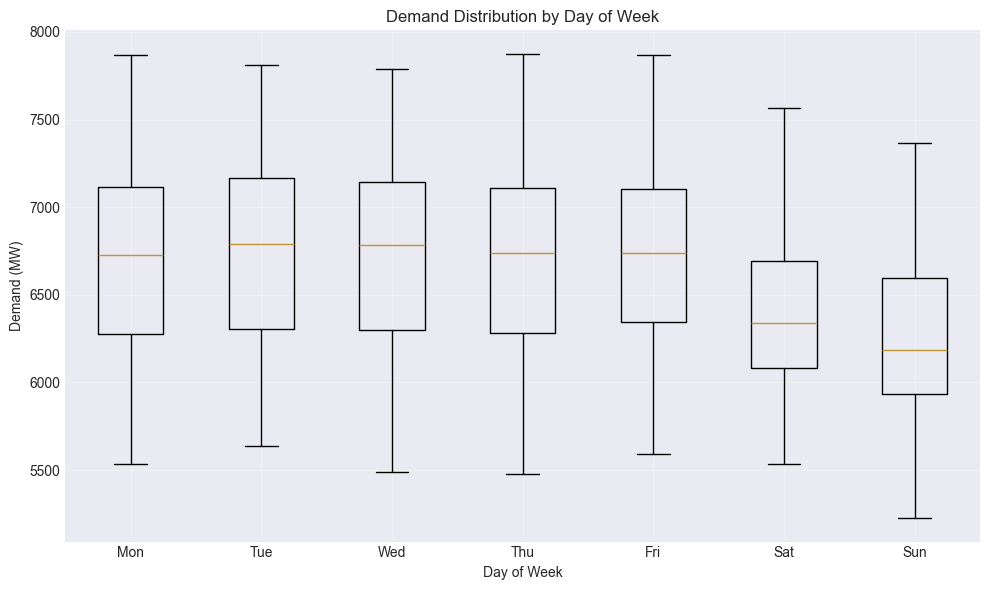

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

groups = vdf["demand"].groupby(vdf.index.dayofweek)

data_by_day = {}
for name, group in groups:
    data_by_day[name] = group.values

sorted_days = sorted(data_by_day.keys())
data_to_plot = [data_by_day[d] for d in sorted_days]

ax.boxplot(data_to_plot, labels=day_names)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Demand (MW)')
ax.set_title('Demand Distribution by Day of Week')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Weekends (Sat & Sun) demand usage was lower than weekdays (Mon - Fri).
    - This could be caused by general businesses are not operating.

C:\Users\Zen7\AppData\Local\Temp\ipykernel_12608\994452708.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot,


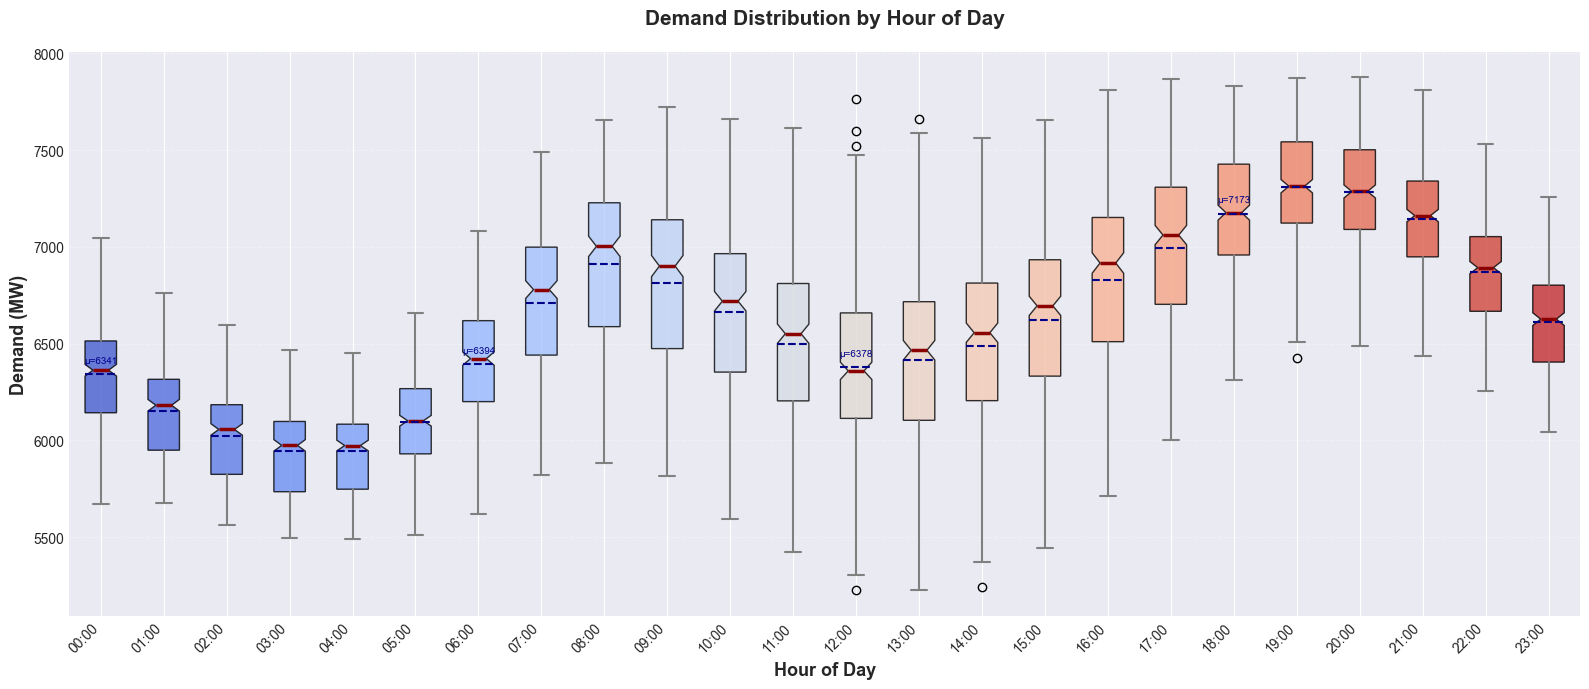

In [25]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, ax = plt.subplots(figsize=(16, 7))

# Group data by hour
groups = vdf["demand"].groupby(vdf.index.hour)

data_by_hour = {}
for name, group in groups:
    data_by_hour[name] = group.values

sorted_hours = sorted(data_by_hour.keys())
data_to_plot = [data_by_hour[h] for h in sorted_hours]

# Create boxplot
bp = ax.boxplot(data_to_plot, 
                labels=[f'{h:02d}:00' for h in sorted_hours],
                patch_artist=True,
                notch=True,         # Notched boxes show confidence intervals
                showmeans=True,
                meanline=True,
                medianprops={'color': 'darkred', 'linewidth': 2.5},
                meanprops={'color': 'darkblue', 'linestyle': '--', 'linewidth': 1.5},
                whiskerprops={'color': 'gray', 'linewidth': 1.5},
                capprops={'color': 'gray', 'linewidth': 1.5})

# Color boxes
colors = sns.color_palette("coolwarm", len(sorted_hours))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(1)

# Add statistics annotations
for i, hour in enumerate(sorted_hours):
    data = data_to_plot[i]
    mean_val = np.mean(data)
    median_val = np.median(data)
    # Add small text with statistics (optional)
    if i % 6 == 0:  # Only for every 6th hour to avoid clutter
        ax.text(i+1, mean_val + 50, f'μ={mean_val:.0f}', 
                ha='center', va='bottom', fontsize=7, color='darkblue')

# Customize
ax.set_xlabel('Hour of Day', fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)', fontsize=13, fontweight='bold')
ax.set_title('Demand Distribution by Hour of Day', fontsize=15, fontweight='bold', pad=20)

# Format x-axis
plt.xticks(rotation=45, ha='right', fontsize=10)

# Grid
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.show()

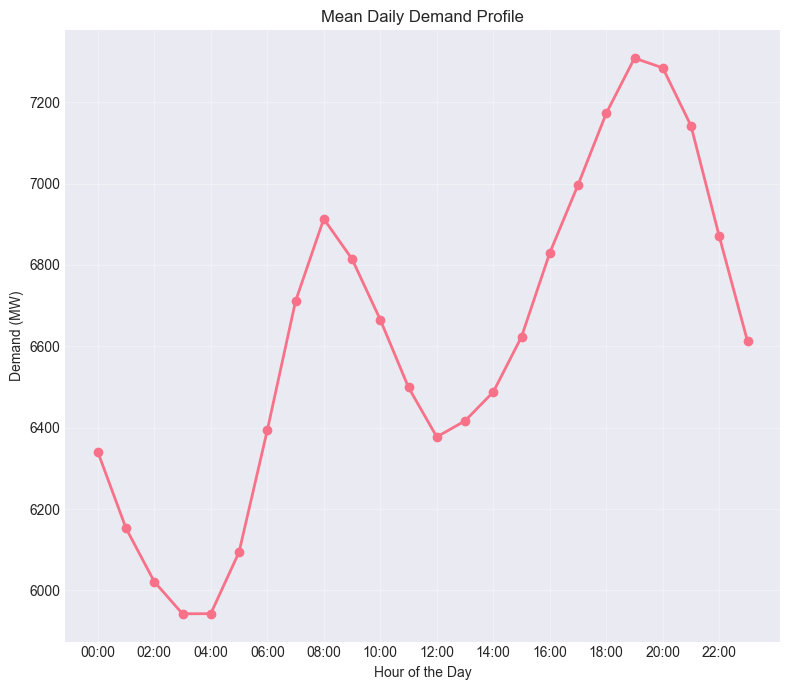

In [26]:
# Convert hourly boxplot to daily mean profile
fig, ax = plt.subplots(figsize=(8, 7))

# Group by hour and calculate mean demand for each hour across all days
hourly_means = vdf["demand"].groupby(vdf.index.hour).mean()

# Create a line plot of mean demand by hour
ax.plot(hourly_means.index, hourly_means.values, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Hour of the Day')
ax.set_ylabel('Demand (MW)')
ax.set_title('Mean Daily Demand Profile')
ax.grid(True, alpha=0.3)

# Set x-axis ticks to show all hours
ax.set_xticks(range(0, 24, 2))  # Show every 2 hours
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])

plt.tight_layout()
plt.show()

- Daily Demand usage was highest at 7pm.
- Daily Demand usage was lowest at 3am or 4am. 

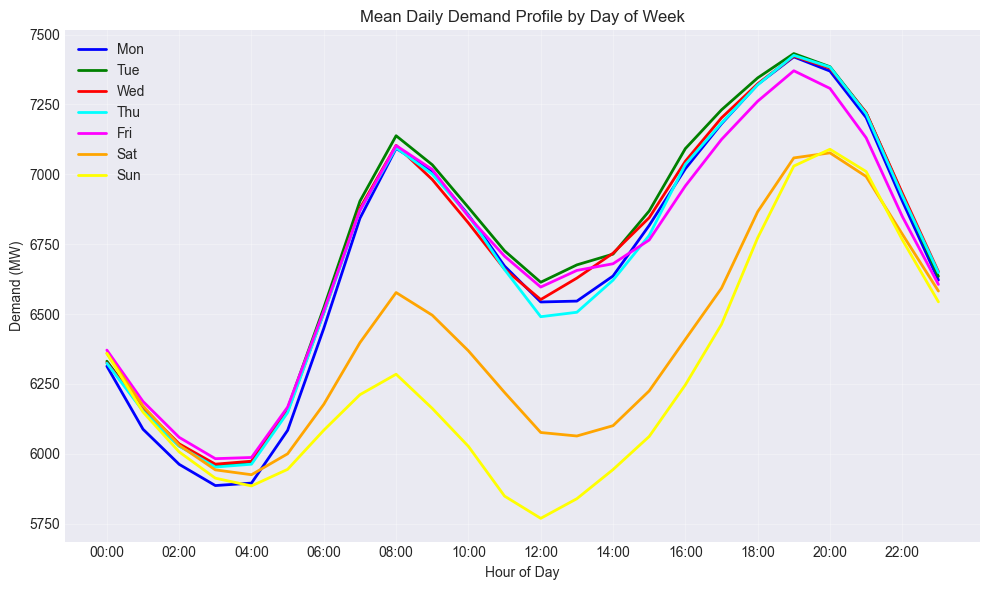

In [27]:
# Convert to daily profile lines by day of week
fig, ax = plt.subplots(figsize=(10, 6))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange', 'yellow']

# Group by hour and day of week
hourly_by_day = vdf["demand"].groupby([vdf.index.hour, vdf.index.dayofweek]).mean().unstack()

# Plot each day of week as a separate line
for day in range(7):
    ax.plot(hourly_by_day.index, hourly_by_day[day].values, 
            label=day_names[day], color=colors[day], linewidth=2)

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Demand (MW)')
ax.set_title('Mean Daily Demand Profile by Day of Week')
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Weekdays (Mon-Fri): Shows higher overall demand due to commercial/industrial activity.

- Weekend (Sat-Sun): Show lower demand due to no office commuting.

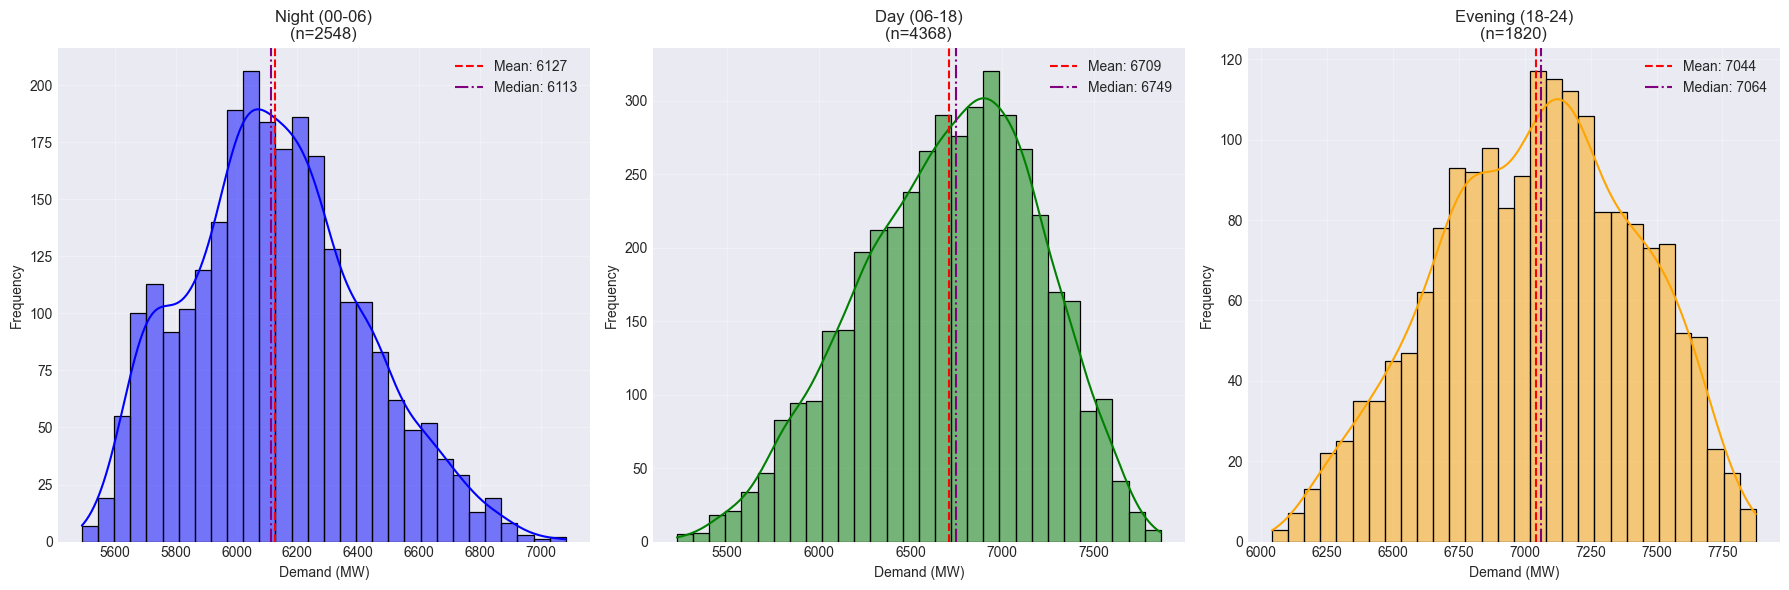

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define periods
vdf['hour'] = vdf.index.hour
vdf['period'] = pd.cut(vdf['hour'], 
                       bins=[-1, 6, 18, 23], 
                       labels=['Night (00-06)', 'Day (06-18)', 'Evening (18-24)'])

# Plot histograms for each period
for i, period in enumerate(['Night (00-06)', 'Day (06-18)', 'Evening (18-24)']):
    data = vdf[vdf['period'] == period]['demand']
    sns.histplot(data, bins=30, kde=True, ax=axes[i], color=['blue', 'green', 'orange'][i])
    axes[i].set_title(f'{period}\n(n={len(data)})', fontsize=12)
    axes[i].set_xlabel('Demand (MW)')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)
    
    # Add mean and median lines
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.0f}')
    axes[i].axvline(data.median(), color='purple', linestyle='-.', label=f'Median: {data.median():.0f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

- Night: 
    - Lowest demand (mean of 6127 MW)
    - Approximately normal or slightly right-skewed (longer tail on the higher end).
- Day: 
    - Highest demand (mean of 6709 MW)
    - Slightly left-skwed (longer tail on the lower end).
- Evening: 
    - Moderate demand (mean of 7044 MW)
    - Approximately normal distribution.

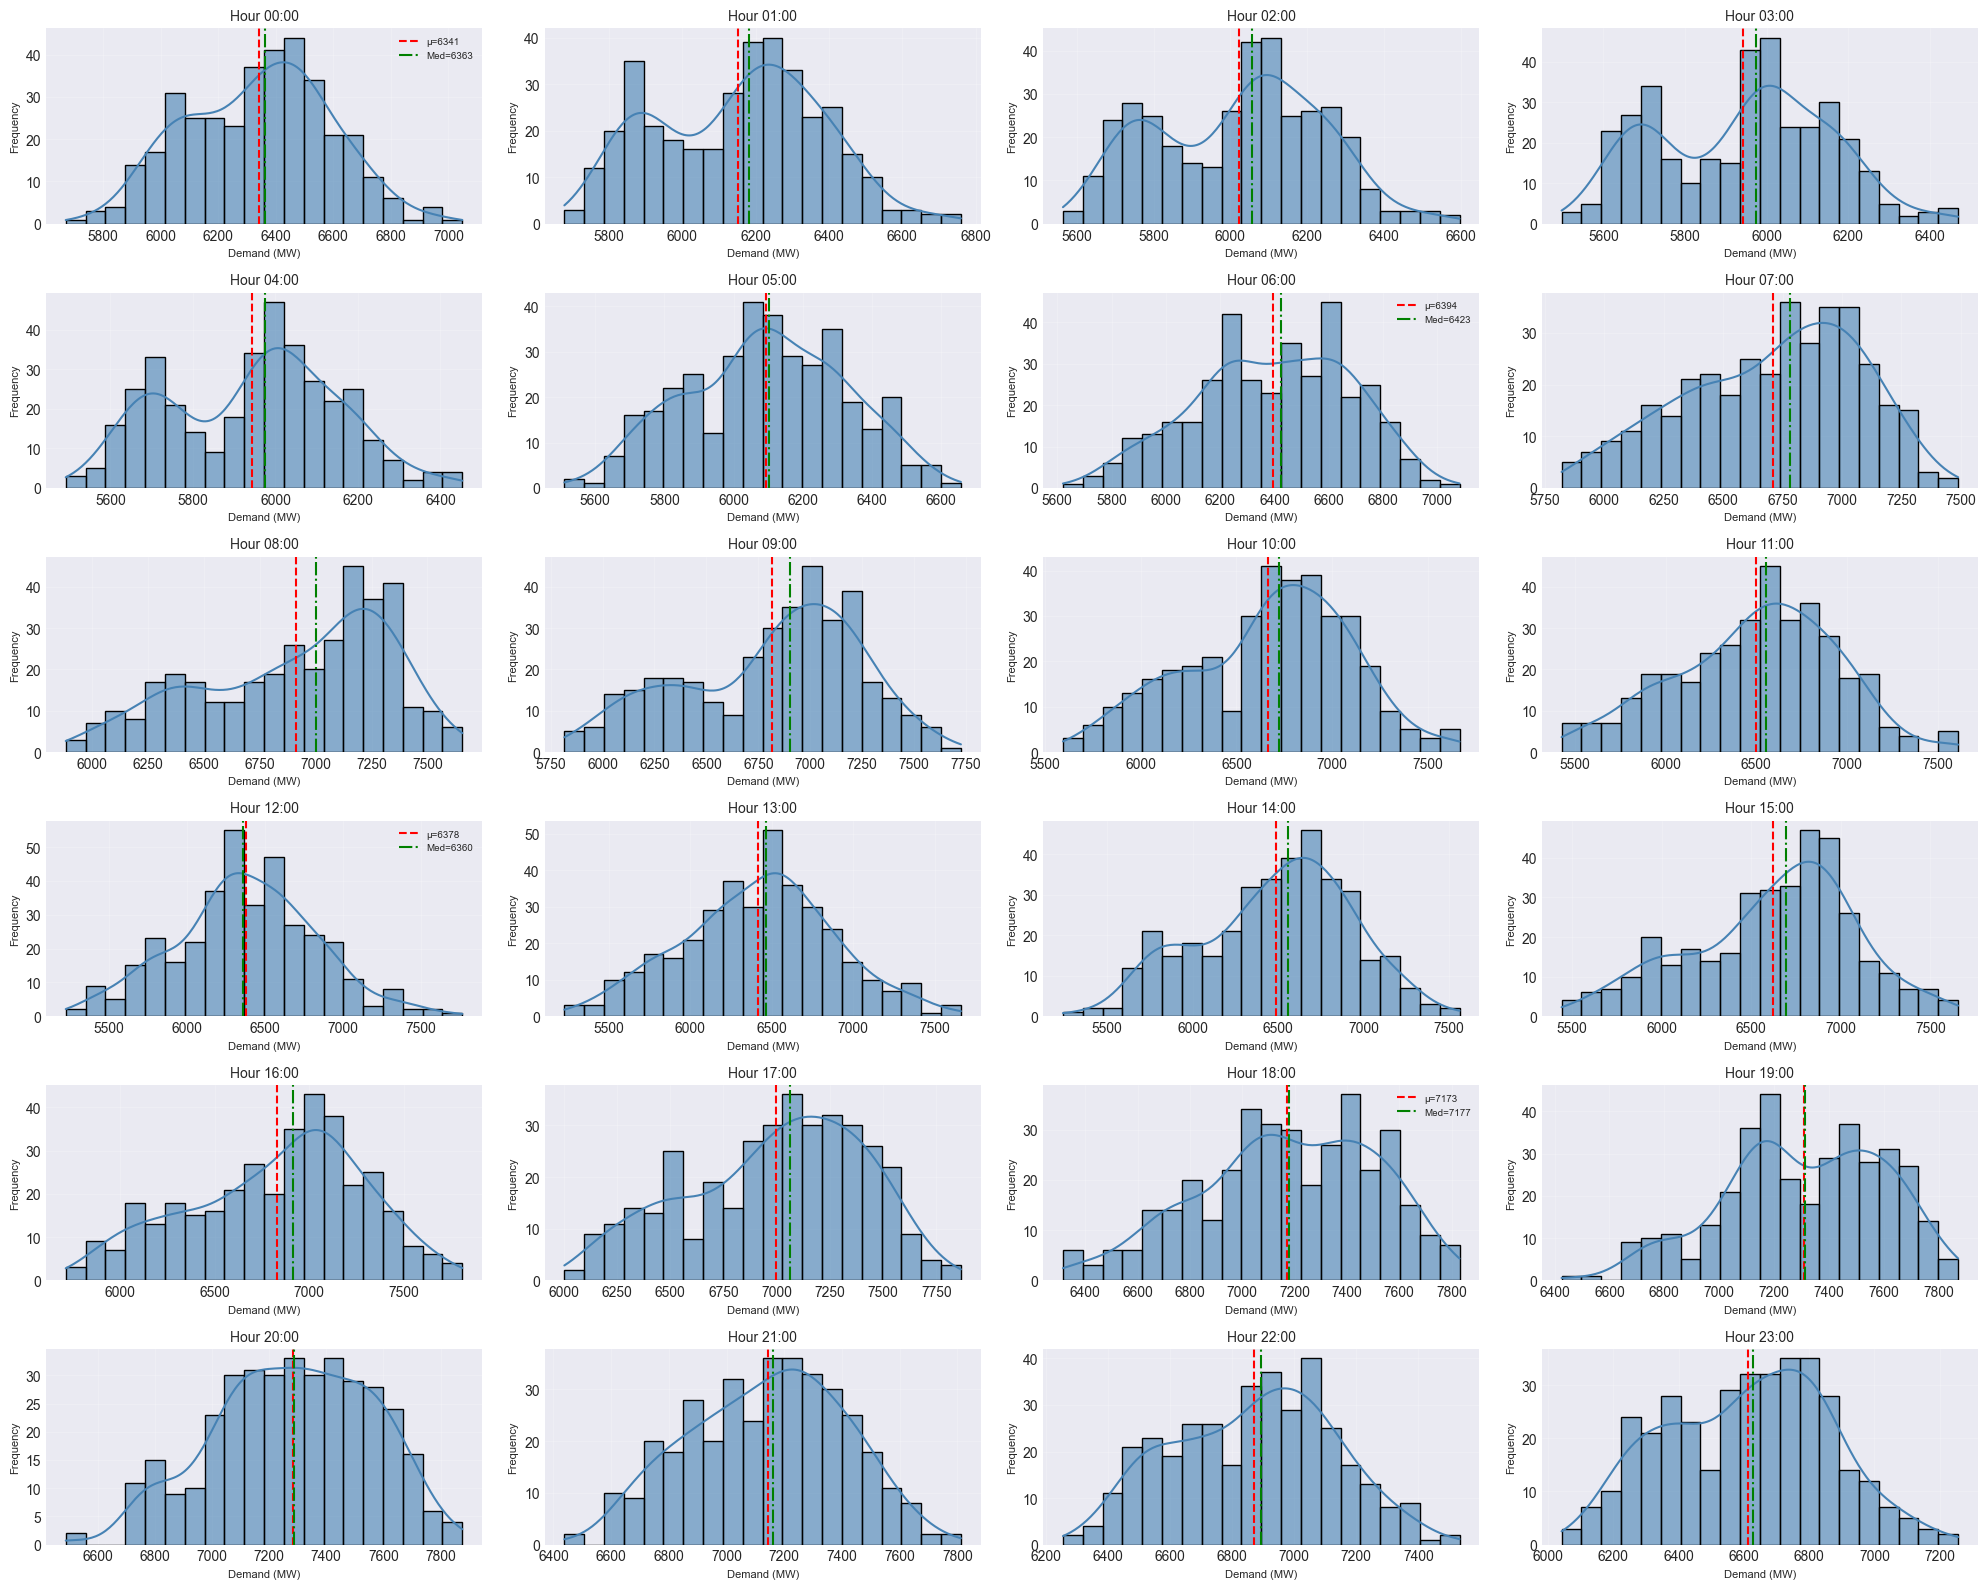

In [29]:
# Create a grid of histograms by hour
fig, axes = plt.subplots(6, 4, figsize=(20, 16))
axes = axes.flatten()

vdf['hour'] = vdf.index.hour

for hour in range(24):
    ax = axes[hour]
    data = vdf[vdf['hour'] == hour]['demand']
    
    # Histogram with KDE
    sns.histplot(data, bins=20, kde=True, ax=ax, color='steelblue', alpha=0.6)
    
    # Add mean and median
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.0f}')
    ax.axvline(data.median(), color='green', linestyle='-.', linewidth=1.5, label=f'Med={data.median():.0f}')
    
    ax.set_title(f'Hour {hour:02d}:00', fontsize=10)
    ax.set_xlabel('Demand (MW)', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.grid(True, alpha=0.2)
    
    # Only show legend for some subplots to avoid clutter
    if hour % 6 == 0:
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

00:00 - 03:00: Normal distribution (overnight low demand).

03:00 - 06:00: Right skew (morning ramp-up begins).

06:00 - 15:00: Left skew (daytime peak period).

15:00 - 18:00: Slight right skew with possible bimodality (afternoon/evening transition).

18:00 - 20:00: Normal distribution (evening plateau).

20:00 - 23:00: Right to left skew (evening decline).

23:00 - 00:00: Normal distribution (returning to overnight low).

- The take-away:
    - Monthly variability of each hourly slice
    - Average variability for the 6 month for each hour

## 2. Feature engineering


In [30]:
# Check frequency 
time_diff = df.index.to_series().diff()

# Shows how often each 30 min time gap occur, which is 47 (1 day), _ (30 days) 
print(time_diff.value_counts()) 

timestamp
0 days 00:30:00    8735
Name: count, dtype: int64


In [31]:
# Create calendar features.
df["hour"] = df.index.hour

df["minute"] = df.index.minute

df["day_of_week"] = df.index.dayofweek

df["day_of_month"] = df.index.day

df["month"] = df.index.month

df["quarter"] = df.index.quarter

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [32]:
# cyclical encoding
# It makes program thinks that 0 and 23 are close together like a clock.
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

In [33]:
# Look at multiple past "demand" values, and assign lag features to it. 
TARGET = "demand"
df["lag_1"] = df[TARGET].shift(1) # 30 min
df["lag_2"] = df[TARGET].shift(2) # 1 hour
df["lag_48"] = df[TARGET].shift(48) # Yesterday
df["lag_96"] = df[TARGET].shift(96) # 2 days ago
df["lag_336"] = df[TARGET].shift(336) # 1 week ago

In [34]:
# Rolling statistics.
df["rolling_mean_48"] = (
    df[TARGET]
    .shift(1)
    .rolling(48)
    .mean()
)

df["rolling_std_48"] = (
    df[TARGET]
    .shift(1)
    .rolling(48)
    .std()
)

# 1 week
df["rolling_mean_336"] = (
    df[TARGET]
    .shift(1)
    .rolling(336)
    .mean()
)

In [35]:
df["solar_lag_1"] = df["solar"].shift(1)

df["usep_lag_1"] = df["usep"].shift(1)

In [36]:
df = df.dropna()

### 3. BASELINE MODEL


In [37]:
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

y_train = train[TARGET]
y_test = test[TARGET]

In [38]:
# BASELINE 1 (Last hour)
last_value_pred = test["lag_2"]
mae_last = mean_absolute_error(
    y_test,
    last_value_pred
)

rmse_last = np.sqrt(
    mean_squared_error(
        y_test,
        last_value_pred
    )
)

# BASELINE 2 (1 Day before)
yesterday_pred = test["lag_48"]
mae_day = mean_absolute_error(
    y_test,
    yesterday_pred
)

rmse_day = np.sqrt(
    mean_squared_error(
        y_test,
        yesterday_pred
    )
)

# BASELINE 3 (1 Week before)
week_pred = test["lag_336"]
mae_week = mean_absolute_error(
    y_test,
    week_pred
)

rmse_week = np.sqrt(
    mean_squared_error(
        y_test,
        week_pred
    )
)

# Baseline 4 (1 absolute mean day before)
rolling_pred = test["rolling_mean_48"]
mae_roll = mean_absolute_error(
    y_test,
    rolling_pred
)

rmse_roll = np.sqrt(
    mean_squared_error(
        y_test,
        rolling_pred
    )
)

In [39]:

results = pd.DataFrame(
    {
        "Model": [
            "Last Value",
            "Yesterday Same Time",
            "Last Week Same Time",
            "Rolling Mean 48"
        ],
        "MAE": [
            mae_last,
            mae_day,
            mae_week,
            mae_roll
        ],
        "RMSE": [
            rmse_last,
            rmse_day,
            rmse_week,
            rmse_roll
        ]
    }
)

results.sort_values(
    "MAE"
)

,Model,MAE,RMSE
0,Last Value,182.826438,224.334282
2,Last Week Same Time,240.406066,342.522061
1,Yesterday Same Time,282.230280,416.888124
3,Rolling Mean 48,418.893232,491.223526


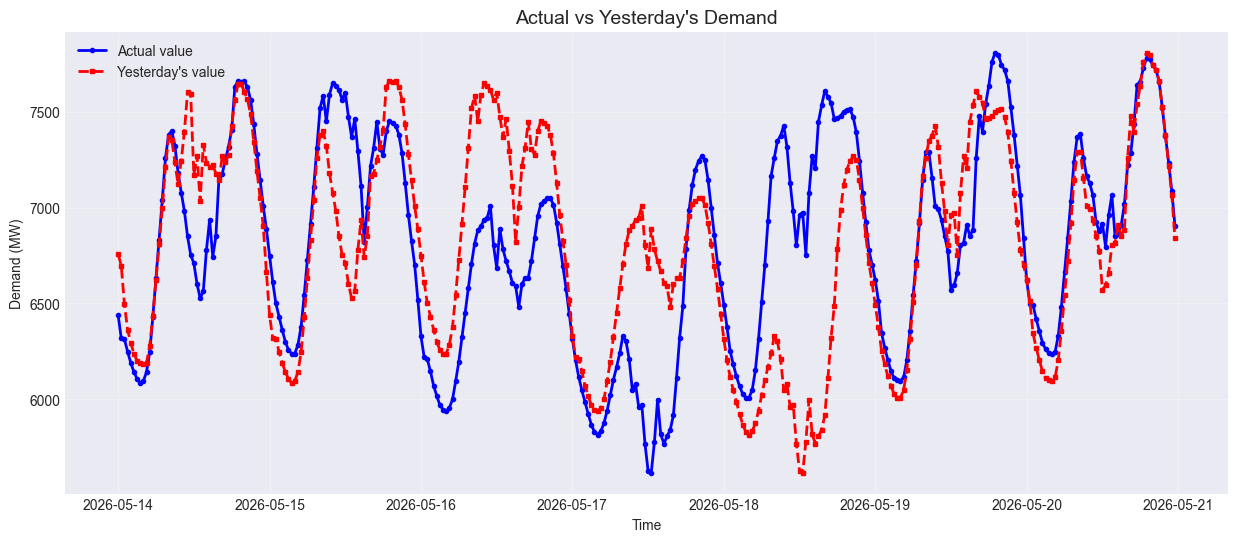

In [40]:
plot_df = test.iloc[:336]

plt.figure(figsize=(15,6))

plt.plot(
    plot_df.index,
    plot_df["demand"],
    label="Actual value",
    color='blue',
    linewidth=2,
    marker='o',
    markersize=3
)

plt.plot(
    plot_df.index,
    plot_df["lag_48"],
    label="Yesterday's value",
    color='red',
    linewidth=2,
    linestyle='--',
    marker='s',
    markersize=3
)

plt.legend()
plt.title('Actual vs Yesterday\'s Demand', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.show()

#### 4. PROPHET MODEL

In [41]:
import holidays
from datetime import datetime
START_DATE = "2025-01-01"  # Default start date for historical data
END_DATE = datetime.now().strftime("%Y-%m-%d") # today

def get_singapore_holidays(start_year: int, end_year: int) -> pd.DataFrame:
    sg = holidays.Singapore(years=range(start_year, end_year + 1))
    rows = []
    
    for day, name in sg.items():
        # Strip special characters so Prophet treats the names as clean string identifiers
        clean_name = str(name).replace("'", "").replace(",", "").replace(" ", "_").lower()
        
        rows.append({
            "holiday": clean_name,
            "ds": pd.Timestamp(day), # Prophet expects 'ds'
            "lower_window": -1,       # Capture the Eve effect
            "upper_window": 1,        # Capture the day-after effect
        })
        
    return pd.DataFrame(rows)

# Generate the native holiday dataframe
holidays_df = get_singapore_holidays(
    pd.to_datetime(START_DATE).year, 
    pd.to_datetime(END_DATE).year
)

In [42]:
from prophet import Prophet

# Convert timestamp from index to normal column (Prophet won't work if there's an index column)
prophet_df = df.reset_index()

# Prophet expect column names of "y" (target value) and "ds" (datestamp)
prophet_df = prophet_df.rename(
    columns={
        "timestamp": "ds",
        "demand": "y"
    }
)

prophet_df = prophet_df[
    [
        "ds",
        "y",
        "solar",
        "usep"
    ]
]

# Chronological split
# The reason of not doing the "train_test_split" method is to prevent "future" data from appearing in training data.
# first 80% = past data (train)
# last 20% = future data (test)
split_idx = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:split_idx]
test = prophet_df.iloc[split_idx:]

In [43]:
# Create and train the model
model = Prophet(
    holidays=holidays_df,
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=True
)

model.add_regressor("solar")

model.add_regressor("usep")

model.fit(train)

future = test[
    [
        "ds",
        "solar",
        "usep"
    ]
]

forecast = model.predict(future)

forecast[
    [
        "ds",
        "yhat",
        "trend"
    ]
].head()

12:53:29 - cmdstanpy - INFO - Chain [1] start processing
12:53:30 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,trend
0,2026-05-14 00:00:00,6748.100179,6792.760564
1,2026-05-14 00:30:00,6634.700814,6792.754311
2,2026-05-14 01:00:00,6544.503660,6792.748057
3,2026-05-14 01:30:00,6459.759205,6792.741804
4,2026-05-14 02:00:00,6389.080000,6792.735551


In [44]:
# Evaluate Prophet
prophet_mae = mean_absolute_error(
    test["y"],
    forecast["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        forecast["yhat"]
    )
)

print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)

MAE: 161.97003732491777
RMSE: 207.09334781443187


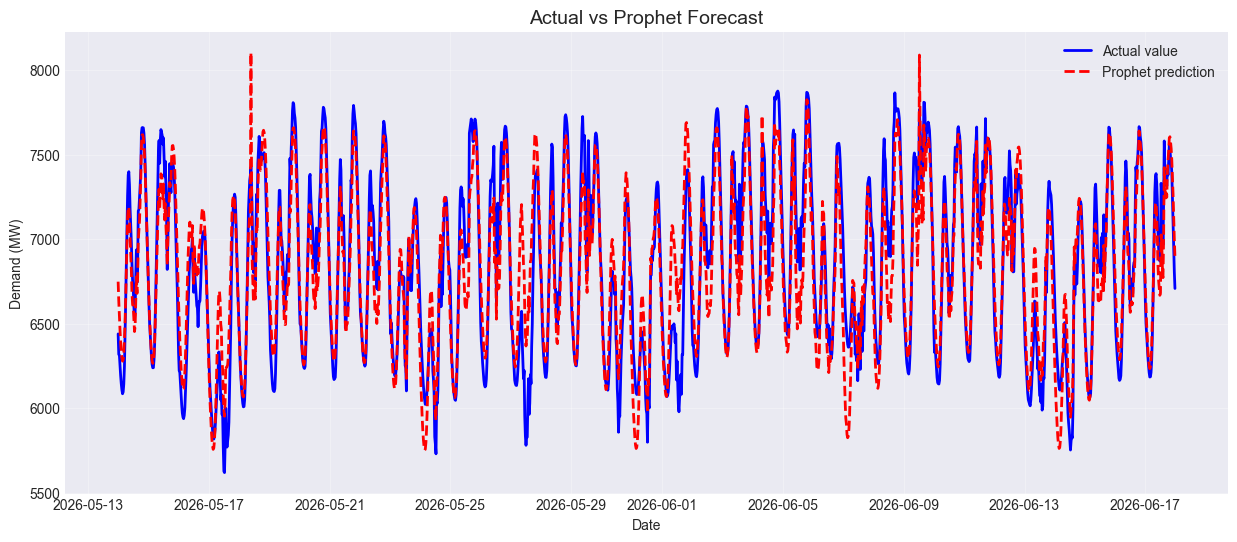

In [45]:
plt.figure(figsize=(15,6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual value",
    color='blue',  # Explicit color
    linewidth=2
)

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Prophet prediction",
    color='red',  # Different explicit color
    linewidth=2,
    linestyle='--'  # Dashed line to differentiate
)

plt.legend()
plt.title('Actual vs Prophet Forecast', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.grid(True, alpha=0.3)
plt.show()

### 5. finding top 2 skforecast models, and fine-tuning them

In [46]:
from lightgbm import LGBMRegressor

from skforecast.recursive import ForecasterRecursive

df = df.sort_index().asfreq("30min")

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

feature_cols = [
    "solar",
    "usep",

    "hour",
    "day_of_week",
    "is_weekend",

    "hour_sin",
    "hour_cos",

    "rolling_mean_48",
    "rolling_std_48",
    "rolling_mean_336",
]

X_train = train[feature_cols]
X_test = test[feature_cols]
y_train = train["demand"]
y_test = test["demand"]

In [47]:
# ALL MODELS 
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)

REGRESSORS = {
    "LightGBM": (
        LGBMRegressor,
        {
            "n_estimators": 100,
            "learning_rate": 0.1,
            "max_depth": 5,
            "random_state": 42,
            "verbose": -1,
        },
    ),
    "RandomForest": (
        RandomForestRegressor,
        {
            "n_estimators": 200,
            "max_depth": 10,
            "random_state": 42,
            "n_jobs": -1,
        },
    ),
    "GradientBoosting": (
        GradientBoostingRegressor,
        {
            "n_estimators": 100,
            "learning_rate": 0.1,
            "max_depth": 5,
            "random_state": 42,
        },
    ),
    "ExtraTrees": (
        ExtraTreesRegressor,
        {
            "n_estimators": 200,
            "max_depth": 10,
            "random_state": 42,
            "n_jobs": -1,
        },
    ),
}


In [48]:
# ALL MODELS
results = []

for name, (model_class, params) in REGRESSORS.items():

    regressor = model_class(**params)

    forecaster = ForecasterRecursive(
        regressor,
        lags=[1,2,48,96,336]
    )

    forecaster.fit(
        y=y_train,
        exog=X_train
    )

    predictions = forecaster.predict(
        steps=len(y_test),
        exog=X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
results_df.sort_values("MAE")

,Model,MAE,RMSE
0,LightGBM,140.667614,196.290702
3,ExtraTrees,179.032342,232.329575
2,GradientBoosting,183.896685,254.463138
1,RandomForest,192.705119,263.273934


In [49]:
# Settings for finding best hyper-parameters
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

def create_lag_features(df):
    
    data = df.copy()
    lags = [
        1,
        2,
        3,
        4,
        5,
        6,
        12,
        24,
        48,
        96,
        336,
    ]

    for lag in lags:
        data[f"lag_{lag}"] = data["demand"].shift(lag)
    data = data.dropna()
    return data

# Prepare data
data = create_lag_features(df)

target = "demand"

feature_cols = [
    col
    for col in data.columns
    if col != target
]

psplit_idx = int(len(data) * 0.8)

ptrain_data = data.iloc[:psplit_idx]
ptest_data = data.iloc[psplit_idx:]

pX_train = ptrain_data[feature_cols]
py_train = ptrain_data[target]

pX_test = ptest_data[feature_cols]
py_test = ptest_data[target]

# Create the walk-forward splitting mechanism (keeps past and future isolated)
tscv = TimeSeriesSplit(
    n_splits=5
)
 
mae_scorer = make_scorer(
    mean_absolute_error,
    greater_is_better=False
)

In [50]:
# Finding best parameter for lightBGM
model = LGBMRegressor(random_state=42, verbose=-1)

param_distributions = {
    "n_estimators": randint(100, 1000),
    "learning_rate": uniform(0.01, 0.19),
    "max_depth": randint(3, 15),
    "num_leaves": randint(20, 200),
    "min_child_samples": randint(5, 100),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 2),
    "reg_lambda": uniform(0, 2),
}

bgm_random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=30,
    cv=tscv,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

bgm_random_search.fit(pX_train, py_train)

print(f"\nBest lightGBM Parameters:{bgm_random_search.best_params_}")
print(f"Best CV MAE: {abs(bgm_random_search.best_score_)}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best lightGBM Parameters:{'colsample_bytree': np.float64(0.989465534702127), 'learning_rate': np.float64(0.06394498520011849), 'max_depth': 4, 'min_child_samples': 70, 'n_estimators': 921, 'num_leaves': 182, 'reg_alpha': np.float64(1.303922519005201), 'reg_lambda': np.float64(0.44853861892111957), 'subsample': np.float64(0.8848716885390143)}
Best CV MAE: 48.451233172023606


In [51]:
# Finding best parameter for ExtraTree
et_model = ExtraTreesRegressor(random_state=42, n_jobs=1)

et_param_distributions = {
    "n_estimators": randint(100, 1000),
    "max_depth": randint(3, 30),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ['sqrt', 'log2', 0.5, 0.7, 0.9],
    "bootstrap": [True],
}

et_random_search = RandomizedSearchCV(
    estimator=et_model,
    param_distributions=et_param_distributions,
    n_iter=30,
    cv=tscv,
    scoring=mae_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

et_random_search.fit(pX_train, py_train)
 
print(f"\nBest ExtraTrees Parameters:{et_random_search.best_params_}")
print(f"Best CV MAE: {abs(et_random_search.best_score_):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best ExtraTrees Parameters:{'bootstrap': True, 'max_depth': 17, 'max_features': 0.9, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 620}
Best CV MAE: 60.3581


In [52]:
y_train.index.to_series().diff().value_counts()

timestamp
0 days 00:30:00    6719
Name: count, dtype: int64

- Make sure frequncy is 30 min.
    - You can check it with `print(df.index.freq)`

In [53]:
# Create and Train LightGBM model (bgm_forecaster)
bgm = LGBMRegressor(
    **bgm_random_search.best_params_,
    verbosity=-1
)

bgm_forecaster = ForecasterRecursive(
    bgm,
    lags=[1,2,48,96,336]
)

bgm_forecaster.fit(
    y=y_train,
    exog=X_train
)

predictions = bgm_forecaster.predict(
    steps=len(test),
    exog=X_test
)

lgbm_mae = mean_absolute_error(
    y_test,
    predictions
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 156.9940949432942
RMSE: 209.56078433170873


In [54]:
# Create and Train ExtraTree model (et_forecaster)
etr = ExtraTreesRegressor(
    **et_random_search.best_params_,
    #verbose=-1
)

et_forecaster = ForecasterRecursive(
    etr,
    lags=[1,2,48,96,336]
)

et_forecaster.fit(
    y=y_train,
    exog=X_train
)

predictions = et_forecaster.predict(
    steps=len(test),
    exog=X_test
)

et_mae = mean_absolute_error(
    y_test,
    predictions
)

et_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE:", et_mae)
print("RMSE:", et_rmse)

MAE: 152.50011720190014
RMSE: 205.53082857073608


#### 6. Model comparsion

In [55]:
results = pd.DataFrame(
    {
        "Model": [
            "Last Value",
            "Yesterday Same Time",
            "Last Week Same Time",
            "Rolling Mean",
            "Prophet",
            "LightGBM",
            "ExtraTree"
        ],
        "MAE": [
            mae_last,
            mae_day,
            mae_week,
            mae_roll,
            prophet_mae,
            lgbm_mae,
            et_mae
        ],
        "RMSE": [
            rmse_last,
            rmse_day,
            rmse_week,
            rmse_roll,
            prophet_rmse,
            lgbm_rmse,
            et_rmse
        ]
    }
)

results.sort_values("MAE")

,Model,MAE,RMSE
6,ExtraTree,152.500117,205.530829
5,LightGBM,156.994095,209.560784
4,Prophet,161.970037,207.093348
0,Last Value,182.826438,224.334282
2,Last Week Same Time,240.406066,342.522061
1,Yesterday Same Time,282.230280,416.888124
3,Rolling Mean,418.893232,491.223526


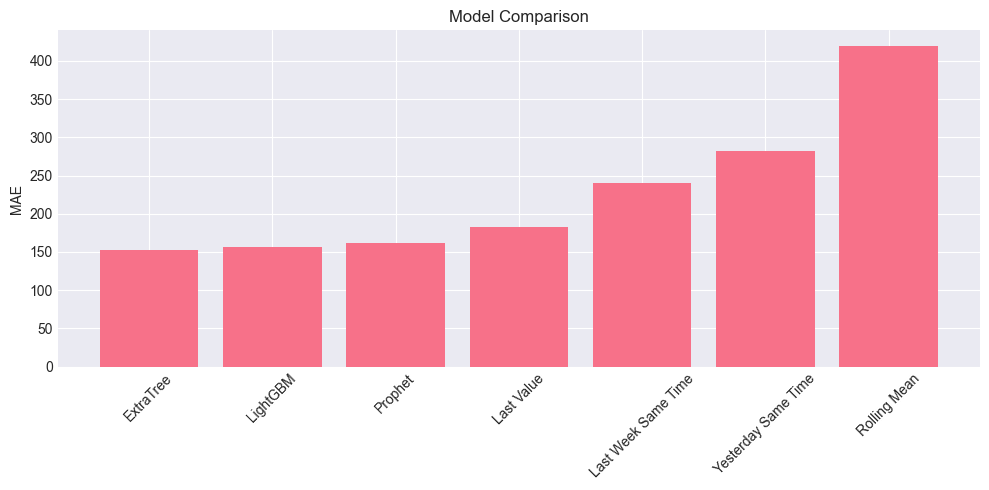

In [56]:
# BAR chart
results_sorted = results.sort_values(
    "MAE"
)

plt.figure(figsize=(10,5))

plt.bar(
    results_sorted["Model"],
    results_sorted["MAE"]
)

plt.ylabel("MAE")

plt.title("Model Comparison")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [57]:
peak_threshold = (
    y_test.quantile(0.95)
)

peak_mask = (
    y_test >= peak_threshold
)

peak_mae = np.mean(
    np.abs(
        y_test[peak_mask]
        -
        predictions[peak_mask]
    )
)

print(f"Top 5% highest demand periods (MAE): {peak_mae}")


Top 5% highest demand periods (MAE): 228.4421449762132


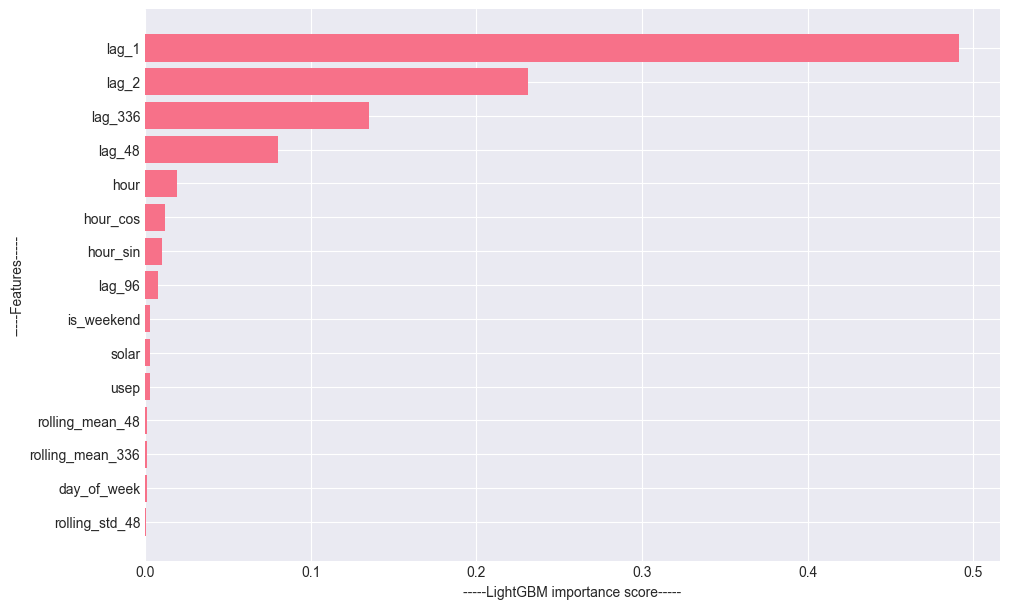

In [58]:
# Shows LightGBM importance socre accross features
importance = (
    forecaster
    .get_feature_importances()
)
importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)
plt.figure(figsize=(10,6))

plt.barh(
    importance["feature"],
    importance["importance"]
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.xlabel("-----LightGBM importance score-----")
plt.ylabel("-----Features-----")
plt.show()


# 7. Findings

1. LightGBM achieved the lowest MAE, followed by ExtraTree.

2. Most important features were:
   - lag_1
   - lag_2

3. Demand exhibits strong short-term autocorrelation.

## Conclusion

- LightGBM, ExtraTree and Phrophet were selected as the production model because it delivered the lowest forecast error while capturing both temporal and operational drivers of electricity demand.

### Future Improvements:
- Include more feature data by implementing a second API (Singpaore NEA):
   - Reasons on getting weather data:
      - Summer Months: if weather data shows temperature and humidity spike, millions of people may turn on their air conditioners during day time. This may lead to higher electrical demands. 
      - Monsoons months: if weather data shows outdoor cool air, causing ambient building temperatures to drop and reducing aircon demand.
      - This will help make Time-series model (skforecast & phrophet) to predict better. 